# 07 - Stability and Artifact Controls

Notebook 06 showed that one concrete FLUX latent-token TDA pipeline can
produce persistence diagrams. This notebook asks the more important
follow-up question:

> Which parts of the diagram survive perturbations, and which parts look
> like artifacts of the sampling pipeline?

The experiment keeps the computation modest but repeats the pipeline
across random seeds, dense-set sizes, landmark counts, and token views.
It also compares the observed FLUX cloud with simple controls and one
synthetic positive control.

## What Counts as Evidence Here?

A visible bar in one diagram is not yet evidence for latent-space
structure. A more credible signal should:

- appear across several random seeds;
- be stronger for observed FLUX tokens than for null controls;
- not depend on exactly one dense-set or landmark setting;
- be interpretable after mapping landmarks back to images;
- be described numerically, not only visually.

This notebook focuses on the first four checks. Cycle-level
interpretability is left for a later notebook.

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import os
import sys
import time
import warnings

for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.max_open_warning"] = 120
sns.set_theme(style="whitegrid", context="notebook")

from notebook_utils.encoder_explorer import (
    DEFAULT_IMAGE_DIR,
    choose_device,
    extract_token_clouds,
    l2_normalize,
    load_project_images,
    seed_everything,
    shape_summary,
    show_image_grid,
)
from notebook_utils.flux_tda import (
    TDASample,
    build_channel_shuffle_dense_sample,
    build_matched_gaussian_sphere_sample,
    build_observed_tda_sample,
    build_random_sphere_sample,
    build_uniform_sphere_sample,
    farthest_point_indices,
    plot_betti_curves,
    plot_diagrams,
    plot_persistence_summary,
    ripser_diagrams,
    select_dense_indices,
    top_persistence_table,
)

## 1. Runtime Knobs

The defaults are deliberately small enough to rerun. Increase
`FLUX_STABILITY_SEEDS`, `TOKENIZER_N_IMAGES`, or the landmark counts
when moving from this exploratory pass to a stronger experiment.

In [2]:
def parse_int_list(text: str) -> list[int]:
    return [int(part.strip()) for part in text.split(",") if part.strip()]


def parse_str_list(text: str) -> list[str]:
    return [part.strip() for part in text.split(",") if part.strip()]


SEED = int(os.environ.get("TOKENIZER_NOTEBOOK_SEED", "72"))
SMOKE = os.environ.get("TOKENIZER_SMOKE", "0") == "1"

N_IMAGES = int(os.environ.get("TOKENIZER_N_IMAGES", "4" if SMOKE else "12"))
BATCH_SIZE = int(os.environ.get("TOKENIZER_BATCH_SIZE", "2" if SMOKE else "4"))
AUTOENCODER_SIZE = int(os.environ.get("TOKENIZER_AUTOENCODER_SIZE", "256"))
IMAGE_DIR = os.environ.get("TOKENIZER_IMAGE_DIR", str(DEFAULT_IMAGE_DIR))

STABILITY_SEEDS = parse_int_list(os.environ.get("FLUX_STABILITY_SEEDS", "72,73" if SMOKE else "72,73,74,75"))
VIEWS = parse_str_list(os.environ.get("FLUX_STABILITY_VIEWS", "sphere,raw,whitened"))
MAXDIM = int(os.environ.get("FLUX_STABILITY_MAXDIM", "2"))
DISTANCE_QUANTILE = float(os.environ.get("FLUX_STABILITY_DISTANCE_QUANTILE", "0.82"))

SWEEP_CONFIGS = pd.DataFrame(
    [
        {"config": "baseline", "n_dense": 600, "n_landmarks": 95, "k_density": 16},
        {"config": "fewer_landmarks", "n_dense": 600, "n_landmarks": 70, "k_density": 16},
        {"config": "smaller_dense", "n_dense": 400, "n_landmarks": 95, "k_density": 16},
    ]
)
if SMOKE:
    SWEEP_CONFIGS = pd.DataFrame(
        [
            {"config": "baseline", "n_dense": 250, "n_landmarks": 45, "k_density": 10},
            {"config": "fewer_landmarks", "n_dense": 250, "n_landmarks": 35, "k_density": 10},
        ]
    )

seed_everything(SEED)
DEVICE = choose_device(force_cpu=os.environ.get("TOKENIZER_FORCE_CPU", "0") == "1")

display(
    pd.DataFrame(
        [
            {"knob": "device", "value": DEVICE},
            {"knob": "smoke", "value": SMOKE},
            {"knob": "n_images", "value": N_IMAGES},
            {"knob": "seeds", "value": STABILITY_SEEDS},
            {"knob": "views", "value": VIEWS},
            {"knob": "maxdim", "value": MAXDIM},
            {"knob": "distance_quantile", "value": DISTANCE_QUANTILE},
            {"knob": "image_dir", "value": IMAGE_DIR},
        ]
    )
)
display(SWEEP_CONFIGS)

,knob,value
0,device,mps
1,smoke,False
2,n_images,12
3,seeds,"[72, 73, 74, 75]"
4,views,"[sphere, raw, whitened]"
5,maxdim,2
6,distance_quantile,0.82
7,image_dir,/Users/vitaly/Code/latent-space-topology/data/...


,config,n_dense,n_landmarks,k_density
0,baseline,600,95,16
1,fewer_landmarks,600,70,16
2,smaller_dense,400,95,16


## 2. Load Data and Encode FLUX Once

We reuse the same FLUX token cloud for every perturbation. The repeated
part of this notebook is the TDA sampling pipeline, not the encoder
forward pass.

,image_id,source,path,label,dataset_index,width,height
0,0,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,0,500,500
1,1,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,345,500,500
2,2,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,693,500,500
3,3,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,1,500,500
4,4,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,346,500,500
5,5,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,694,500,500
6,6,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,2,500,500
7,7,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,347,500,500
8,8,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,695,500,500
9,9,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,3,500,500


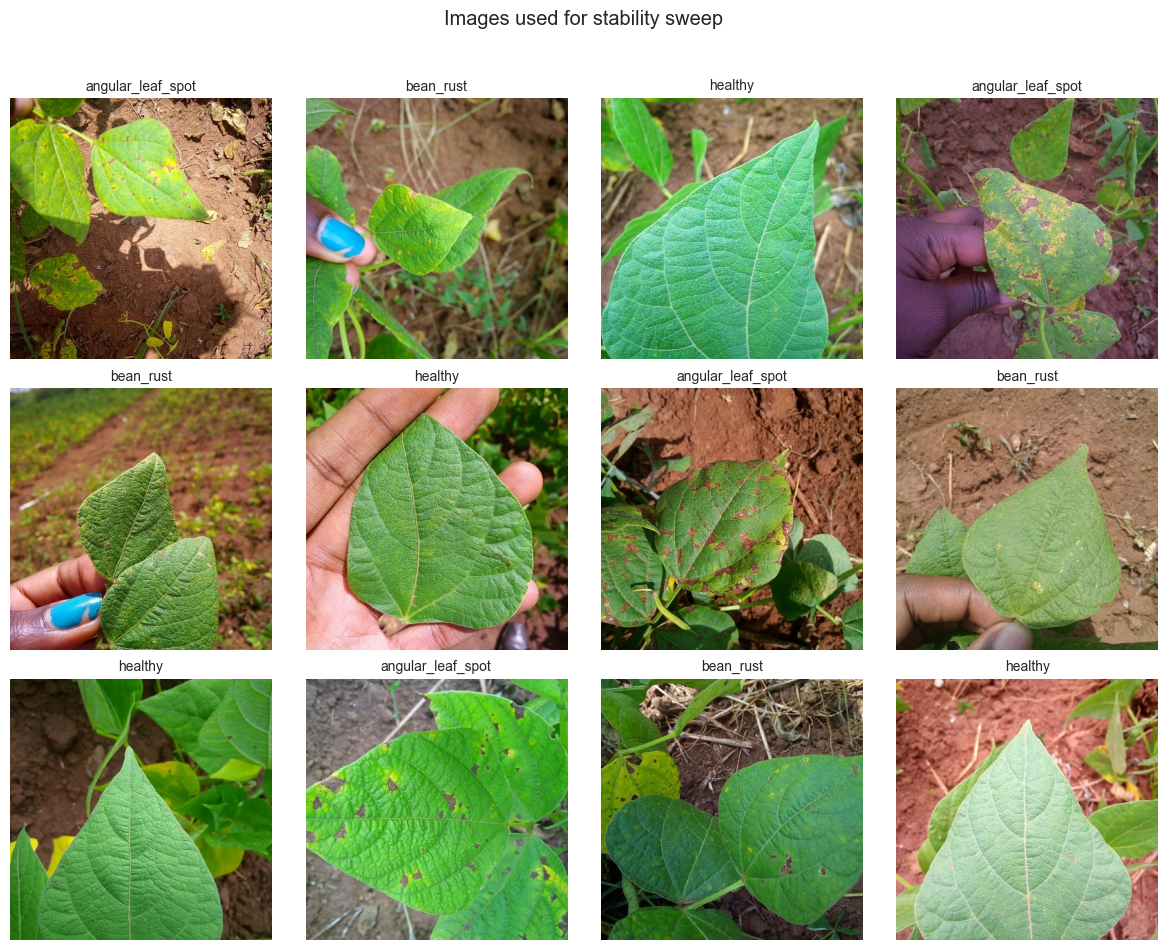

In [3]:
images, image_metadata = load_project_images(N_IMAGES, IMAGE_DIR)
display(image_metadata.head(12))
show_image_grid(images, image_metadata, n=min(12, len(images)), title="Images used for stability sweep")

In [4]:
t0 = time.perf_counter()
token_clouds, failures = extract_token_clouds(
    images,
    image_metadata,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    autoencoder_size=AUTOENCODER_SIZE,
    selected=["flux_vae"],
)
encode_seconds = time.perf_counter() - t0

if not failures.empty:
    display(failures)
flux = token_clouds["flux_vae"]
print(f"encoding seconds: {encode_seconds:.2f}")
display(shape_summary(token_clouds))
display(pd.DataFrame([flux.notes]))

Running flux_vae: diffusers/FLUX.1-vae


/Users/vitaly/Code/latent-space-topology/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  ok: (12288, 16), grid=(32, 32), elapsed=6.6s
encoding seconds: 6.55


,name,family,token_kind,tokens_shape,grid_shape,channel_dim,model_id
0,flux_vae,AutoencoderKL,posterior_mean,"(12288, 16)","(32, 32)",16,diffusers/FLUX.1-vae


,device,latent_shape_bchw,scaling_factor,shift_factor,scaled_latent_mean,scaled_latent_std
0,mps,"(12, 16, 32, 32)",0.3611,0.1159,-0.1058,0.730939


## 3. Views and Summary Helpers

The first artifact check is whether the result depends on the chosen
geometric object:

- `sphere`: L2-normalized token directions on `S^15`;
- `raw`: original FLUX posterior-mean token vectors;
- `whitened`: covariance-whitened token vectors with Euclidean distance.

The persistence scale is different for each view, so we track both raw
persistence and persistence divided by the run's filtration threshold.

In [5]:
def whiten_tokens(x: np.ndarray, eps: float = 1e-5) -> np.ndarray:
    x = x.astype(np.float32)
    centered = x - x.mean(axis=0, keepdims=True)
    cov = np.cov(centered, rowvar=False)
    values, vectors = np.linalg.eigh(cov + np.eye(cov.shape[0]) * eps)
    values = np.maximum(values, eps)
    return (centered @ vectors @ np.diag(1.0 / np.sqrt(values))).astype(np.float32)


def token_view(cloud, view: str) -> np.ndarray:
    raw = cloud.tokens.astype(np.float32)
    if view == "raw":
        return raw
    if view == "sphere":
        return l2_normalize(raw).astype(np.float32)
    if view == "whitened":
        return whiten_tokens(raw)
    raise ValueError(f"unknown view: {view}")


def build_observed_view_sample(cloud, view: str, n_dense: int, n_landmarks: int, k_density: int, seed: int) -> TDASample:
    x = token_view(cloud, view)
    dense_global_idx, dense_kth = select_dense_indices(x, n_dense=n_dense, k=k_density, seed=seed)
    dense_tokens = x[dense_global_idx]
    landmark_local_idx = farthest_point_indices(dense_tokens, n_landmarks=n_landmarks, seed=seed)
    landmark_global_idx = dense_global_idx[landmark_local_idx]
    return TDASample(
        name=f"observed_{view}",
        tokens=dense_tokens[landmark_local_idx],
        source_indices=landmark_global_idx,
        metadata=cloud.token_metadata.iloc[landmark_global_idx].reset_index(drop=True),
        notes={
            "view": view,
            "density": "small kth-neighbor distance",
            "n_dense": len(dense_global_idx),
            "n_landmarks": len(landmark_global_idx),
            "k_density": k_density,
            "dense_kth_median": float(np.median(dense_kth)),
        },
    )


def build_synthetic_circle_sample(dim: int, n_landmarks: int, seed: int, noise: float = 0.025) -> TDASample:
    rng = np.random.default_rng(seed)
    theta = np.linspace(0, 2 * np.pi, n_landmarks, endpoint=False)
    x = np.zeros((n_landmarks, dim), dtype=np.float32)
    x[:, 0] = np.cos(theta)
    x[:, 1] = np.sin(theta)
    if dim > 2:
        x[:, 2:] = rng.normal(scale=noise, size=(n_landmarks, dim - 2))
    x = l2_normalize(x).astype(np.float32)
    return TDASample(
        name="synthetic_circle_positive",
        tokens=x,
        source_indices=np.arange(n_landmarks),
        metadata=pd.DataFrame({"image_id": ["control"] * n_landmarks, "label": ["circle"] * n_landmarks, "h": 0, "w": 0}),
        notes={"control": "noisy circle embedded in the same ambient dimension"},
    )


def summarize_result(result: dict, *, seed: int, config: str, view: str, group: str, n_dense: int, n_landmarks: int, k_density: int) -> pd.DataFrame:
    rows = []
    for dim, diagram in enumerate(result["diagrams"]):
        finite = diagram[np.isfinite(diagram[:, 1])]
        persistence = finite[:, 1] - finite[:, 0] if len(finite) else np.array([])
        rows.append(
            {
                "seed": seed,
                "config": config,
                "view": view,
                "group": group,
                "sample": result["sample"],
                "dim": dim,
                "n_dense": n_dense,
                "n_landmarks": n_landmarks,
                "k_density": k_density,
                "n_features": len(diagram),
                "n_finite": len(finite),
                "max_persistence": float(persistence.max()) if len(persistence) else 0.0,
                "mean_persistence": float(persistence.mean()) if len(persistence) else 0.0,
                "total_persistence": float(persistence.sum()) if len(persistence) else 0.0,
                "top3_persistence": float(np.sort(persistence)[-3:].sum()) if len(persistence) else 0.0,
                "threshold": result["threshold"],
                "max_persistence_fraction": float(persistence.max() / result["threshold"]) if len(persistence) and result["threshold"] > 0 else 0.0,
            }
        )
    return pd.DataFrame(rows)


def run_one(sample: TDASample, *, seed: int, config: str, view: str, group: str, n_dense: int, n_landmarks: int, k_density: int) -> tuple[dict, pd.DataFrame]:
    result = ripser_diagrams(sample, maxdim=MAXDIM, distance_quantile=DISTANCE_QUANTILE)
    result["sample"] = sample.name
    result["notes"] = sample.notes
    summary = summarize_result(
        result,
        seed=seed,
        config=config,
        view=view,
        group=group,
        n_dense=n_dense,
        n_landmarks=n_landmarks,
        k_density=k_density,
    )
    return result, summary

## 4. Run the Stability Sweep

This sweep has two parts:

1. observed FLUX tokens under several views and sampling knobs;
2. sphere-view controls under the baseline sampling knob.

The synthetic circle is a positive control: if `H1` does not stand out
there, this whole pipeline is too weak to trust.

In [6]:
results: dict[tuple, dict] = {}
summaries = []

t0 = time.perf_counter()

for cfg in SWEEP_CONFIGS.to_dict("records"):
    for seed in STABILITY_SEEDS:
        for view in VIEWS:
            sample = build_observed_view_sample(flux, view=view, seed=seed, **{k: cfg[k] for k in ["n_dense", "n_landmarks", "k_density"]})
            result, summary = run_one(sample, seed=seed, config=cfg["config"], view=view, group="observed", **{k: cfg[k] for k in ["n_dense", "n_landmarks", "k_density"]})
            key = (cfg["config"], seed, view, sample.name)
            results[key] = result
            summaries.append(summary)

baseline = SWEEP_CONFIGS.iloc[0].to_dict()
for seed in STABILITY_SEEDS:
    observed, _ = build_observed_tda_sample(
        flux,
        n_dense=int(baseline["n_dense"]),
        n_landmarks=int(baseline["n_landmarks"]),
        k_density=int(baseline["k_density"]),
        seed=seed,
    )
    control_samples = [
        replace(observed, name="observed_sphere_baseline"),
        build_random_sphere_sample(flux, n_landmarks=int(baseline["n_landmarks"]), seed=seed + 101),
        build_uniform_sphere_sample(flux.channel_dim, n_landmarks=int(baseline["n_landmarks"]), seed=seed + 102),
        build_matched_gaussian_sphere_sample(flux, n_landmarks=int(baseline["n_landmarks"]), seed=seed + 103),
        build_channel_shuffle_dense_sample(
            flux,
            n_dense=int(baseline["n_dense"]),
            n_landmarks=int(baseline["n_landmarks"]),
            k_density=int(baseline["k_density"]),
            seed=seed + 104,
        ),
        build_synthetic_circle_sample(flux.channel_dim, n_landmarks=int(baseline["n_landmarks"]), seed=seed + 105),
    ]
    for sample in control_samples:
        group = "positive_control" if "positive" in sample.name else "control"
        if sample.name == "observed_sphere_baseline":
            group = "observed"
        result, summary = run_one(
            sample,
            seed=seed,
            config="control_baseline",
            view="sphere",
            group=group,
            n_dense=int(baseline["n_dense"]),
            n_landmarks=int(baseline["n_landmarks"]),
            k_density=int(baseline["k_density"]),
        )
        key = ("control_baseline", seed, "sphere", sample.name)
        results[key] = result
        summaries.append(summary)

sweep_seconds = time.perf_counter() - t0
summary = pd.concat(summaries, ignore_index=True)

print(f"sweep seconds: {sweep_seconds:.2f}")
print(f"diagram runs: {len(results)}")
display(summary.head())
display(summary.groupby(["group", "sample", "dim"]).size().rename("runs").reset_index())

sweep seconds: 4.77
diagram runs: 60


,seed,config,view,group,sample,dim,n_dense,n_landmarks,k_density,n_features,n_finite,max_persistence,mean_persistence,total_persistence,top3_persistence,threshold,max_persistence_fraction
0,72,baseline,sphere,observed,observed_sphere,0,600,95,16,95,94,1.039958,0.462606,43.484963,2.108157,1.151979,0.902758
1,72,baseline,sphere,observed,observed_sphere,1,600,95,16,109,109,0.091637,0.033571,3.659266,0.260855,1.151979,0.079548
2,72,baseline,sphere,observed,observed_sphere,2,600,95,16,81,81,0.044128,0.016242,1.315613,0.127370,1.151979,0.038306
3,72,baseline,raw,observed,observed_raw,0,600,95,16,95,94,5.967934,4.320461,406.123311,15.386823,11.269696,0.529556
4,72,baseline,raw,observed,observed_raw,1,600,95,16,105,105,0.933737,0.270213,28.372412,2.388353,11.269696,0.082854


,group,sample,dim,runs
0,control,channel_shuffle_dense_sphere,0,4
1,control,channel_shuffle_dense_sphere,1,4
2,control,channel_shuffle_dense_sphere,2,4
3,control,matched_gaussian_then_sphere,0,4
4,control,matched_gaussian_then_sphere,1,4
5,control,matched_gaussian_then_sphere,2,4
6,control,random_sphere_tokens,0,4
7,control,random_sphere_tokens,1,4
8,control,random_sphere_tokens,2,4
9,control,uniform_sphere_control,0,4


## 5. View Sensitivity

This plot asks whether the observed FLUX signal changes when the same
dense-landmark procedure is applied to raw, sphere-normalized, or
whitened tokens.

max_persistence_fraction         n_finite  \
                                                 mean     std     mean   
view     config          dim                                             
raw      baseline        1                     0.0786  0.0092    93.25   
                         2                     0.0490  0.0042    58.00   
         fewer_landmarks 1                     0.0651  0.0056    60.75   
                         2                     0.0474  0.0101    29.75   
         smaller_dense   1                     0.0762  0.0047    77.00   
                         2                     0.0450  0.0021    38.75   
sphere   baseline        1                     0.0834  0.0200   113.50   
                         2                     0.0502  0.0119    90.75   
         fewer_landmarks 1                     0.0709  0.0037    70.75   
                         2                     0.0435  0.0037    42.25   
         smaller_dense   1                     0.0823  0.0165   109.50   
                         2                     0.0504  0.0123    84.25   
whitened baseline        1                     0.1090  0.0054   159.75   
                         2                     0.0701  0.0082   191.50   
         fewer_landmarks 1                     0.1155  0.0122   106.25   
                         2                     0.0713  0.0121   113.50   
         smaller_dense   1                     0.1154  0.0116   150.50   
                         2                     0.0714  0.0080   152.00   

                                      total_persistence          
                                  std              mean     std  
view     config          dim                                     
raw      baseline        1     9.4648           25.7942  2.0590  
                         2    11.6905            9.0159  2.5574  
         fewer_landmarks 1     4.9244           17.7453  2.0271  
                         2     2.2174            5.4052  1.1481  
         smaller_dense   1     3.8297           20.3544  1.0360  
                         2     6.3966            5.8089  1.6567  
sphere   baseline        1     5.1962            3.4798  0.2502  
                         2     6.6521            1.4801  0.1736  
         fewer_landmarks 1     5.1235            2.1346  0.3893  
                         2     5.3774            0.7071  0.1564  
         smaller_dense   1    10.0167            3.1137  0.2858  
                         2     9.6047            1.2011  0.1127  
whitened baseline        1     7.5443           31.3077  1.9879  
                         2     9.4692           19.3171  1.3671  
         fewer_landmarks 1     9.5000           20.6378  1.2426  
                         2    14.7535           12.6063  2.7462  
         smaller_dense   1     2.3805           25.2838  0.8337  
                         2    15.0333           14.9085  1.6197

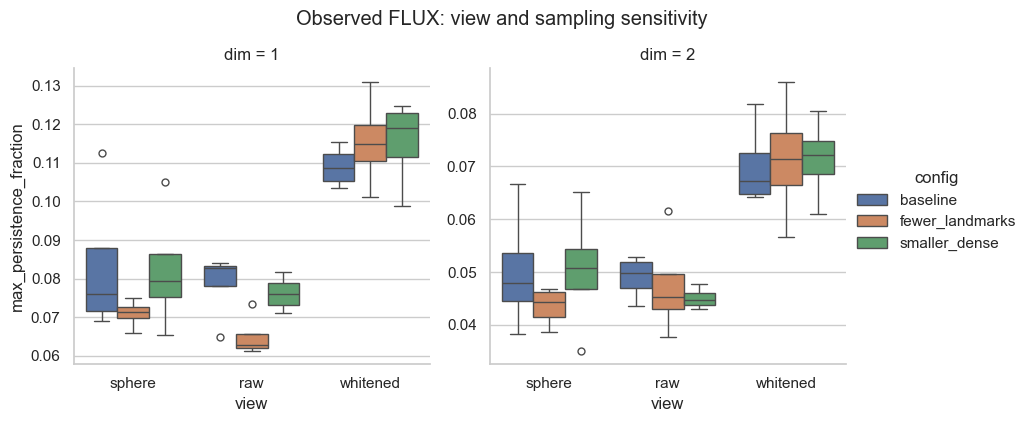

In [7]:
observed = summary[(summary["group"] == "observed") & (summary["config"].isin(SWEEP_CONFIGS["config"]))]
observed_higher = observed[observed["dim"].isin([1, 2])].copy()

display(
    observed_higher
    .groupby(["view", "config", "dim"])
    [["max_persistence_fraction", "n_finite", "total_persistence"]]
    .agg(["mean", "std"])
    .round(4)
)

g = sns.catplot(
    data=observed_higher,
    x="view",
    y="max_persistence_fraction",
    hue="config",
    col="dim",
    kind="box",
    height=4,
    aspect=1.1,
    sharey=False,
)
g.fig.suptitle("Observed FLUX: view and sampling sensitivity", y=1.05)
plt.show()

## 6. Observed Versus Controls

The cleanest comparison is the baseline sphere pipeline. We compare the
observed dense landmarks to simple null clouds and to the synthetic
circle positive control.

max_persistence_fraction         n_finite  \
                                                     mean     std     mean   
sample                       dim                                             
channel_shuffle_dense_sphere 1                     0.1071  0.0130   149.75   
                             2                     0.0681  0.0106   151.50   
matched_gaussian_then_sphere 1                     0.1318  0.0256    68.00   
                             2                     0.0658  0.0100    27.75   
observed_sphere_baseline     1                     0.0834  0.0200   113.50   
                             2                     0.0502  0.0119    90.75   
random_sphere_tokens         1                     0.1364  0.0325    62.50   
                             2                     0.0578  0.0128    22.75   
synthetic_circle_positive    1                     0.8040  0.0040     2.00   
                             2                     0.0023  0.0004    16.75   
uniform_sphere_control       1                     0.1387  0.0065   146.00   
                             2                     0.0776  0.0047   213.00   

                                          top3_persistence          
                                      std             mean     std  
sample                       dim                                    
channel_shuffle_dense_sphere 1     4.1932           0.3406  0.0259  
                             2    14.2009           0.2134  0.0299  
matched_gaussian_then_sphere 1    10.9848           0.4908  0.0283  
                             2     3.5940           0.2326  0.0466  
observed_sphere_baseline     1     5.1962           0.2553  0.0223  
                             2     6.6521           0.1473  0.0177  
random_sphere_tokens         1     1.7321           0.4970  0.1004  
                             2     2.8723           0.2154  0.0374  
synthetic_circle_positive    1     1.4142           1.5490  0.0054  
                             2     2.0616           0.0108  0.0019  
uniform_sphere_control       1    12.8323           0.6113  0.0197  
                             2     9.9331           0.3433  0.0167

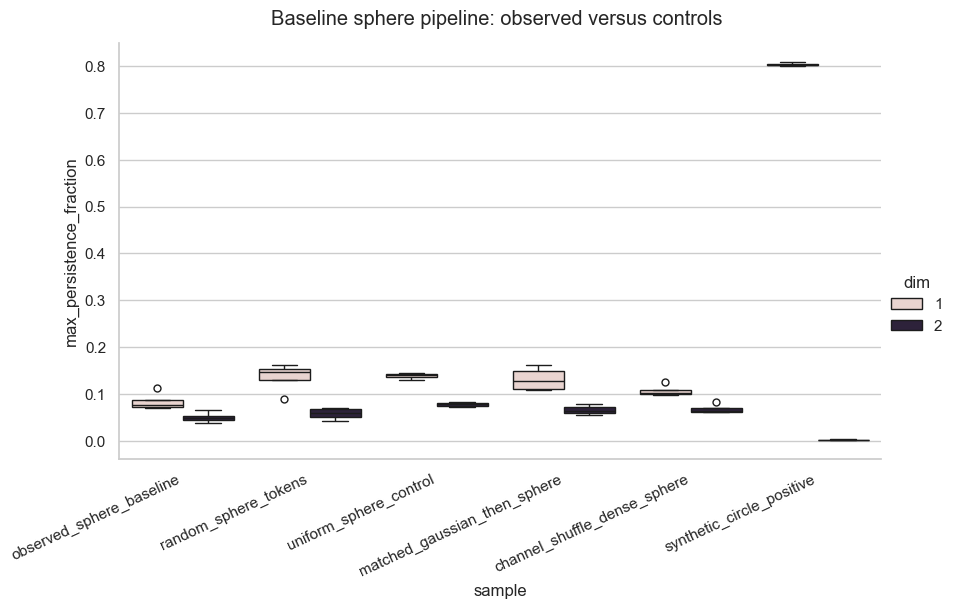

In [8]:
baseline_summary = summary[(summary["config"] == "control_baseline") & (summary["dim"].isin([1, 2]))].copy()

display(
    baseline_summary
    .groupby(["sample", "dim"])
    [["max_persistence_fraction", "n_finite", "top3_persistence"]]
    .agg(["mean", "std"])
    .round(4)
)

g = sns.catplot(
    data=baseline_summary,
    x="sample",
    y="max_persistence_fraction",
    hue="dim",
    kind="box",
    height=5,
    aspect=1.7,
    sharey=False,
)
g.set_xticklabels(rotation=25, horizontalalignment="right")
g.fig.suptitle("Baseline sphere pipeline: observed versus controls", y=1.03)
plt.show()

## 7. Effect-Size Table

This small table compares each sample's mean persistence fraction against
the uniform-sphere control. It is not a statistical test; it is a compact
triage view for deciding what deserves more runs.

In [9]:
effect = (
    baseline_summary
    .groupby(["sample", "dim"], as_index=False)["max_persistence_fraction"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
uniform = effect[effect["sample"] == "uniform_sphere_control"][["dim", "mean"]].rename(columns={"mean": "uniform_mean"})
effect = effect.merge(uniform, on="dim", how="left")
effect["delta_vs_uniform"] = effect["mean"] - effect["uniform_mean"]
effect = effect.sort_values(["dim", "delta_vs_uniform"], ascending=[True, False])
display(effect.round(4))

,index,sample,dim,mean,std,count,uniform_mean,delta_vs_uniform
8,8,synthetic_circle_positive,1,0.8040,0.0040,4,0.1387,0.6653
10,10,uniform_sphere_control,1,0.1387,0.0065,4,0.1387,0.0000
6,6,random_sphere_tokens,1,0.1364,0.0325,4,0.1387,-0.0024
2,2,matched_gaussian_then_sphere,1,0.1318,0.0256,4,0.1387,-0.0069
0,0,channel_shuffle_dense_sphere,1,0.1071,0.0130,4,0.1387,-0.0316
4,4,observed_sphere_baseline,1,0.0834,0.0200,4,0.1387,-0.0553
11,11,uniform_sphere_control,2,0.0776,0.0047,4,0.0776,0.0000
1,1,channel_shuffle_dense_sphere,2,0.0681,0.0106,4,0.0776,-0.0095
3,3,matched_gaussian_then_sphere,2,0.0658,0.0100,4,0.0776,-0.0118
7,7,random_sphere_tokens,2,0.0578,0.0128,4,0.0776,-0.0198


## 8. Representative Diagrams

Summary plots are the main evidence in this notebook, but a few
representative diagrams help sanity-check the numbers. These diagrams
all use the first stability seed and the baseline sphere setup.

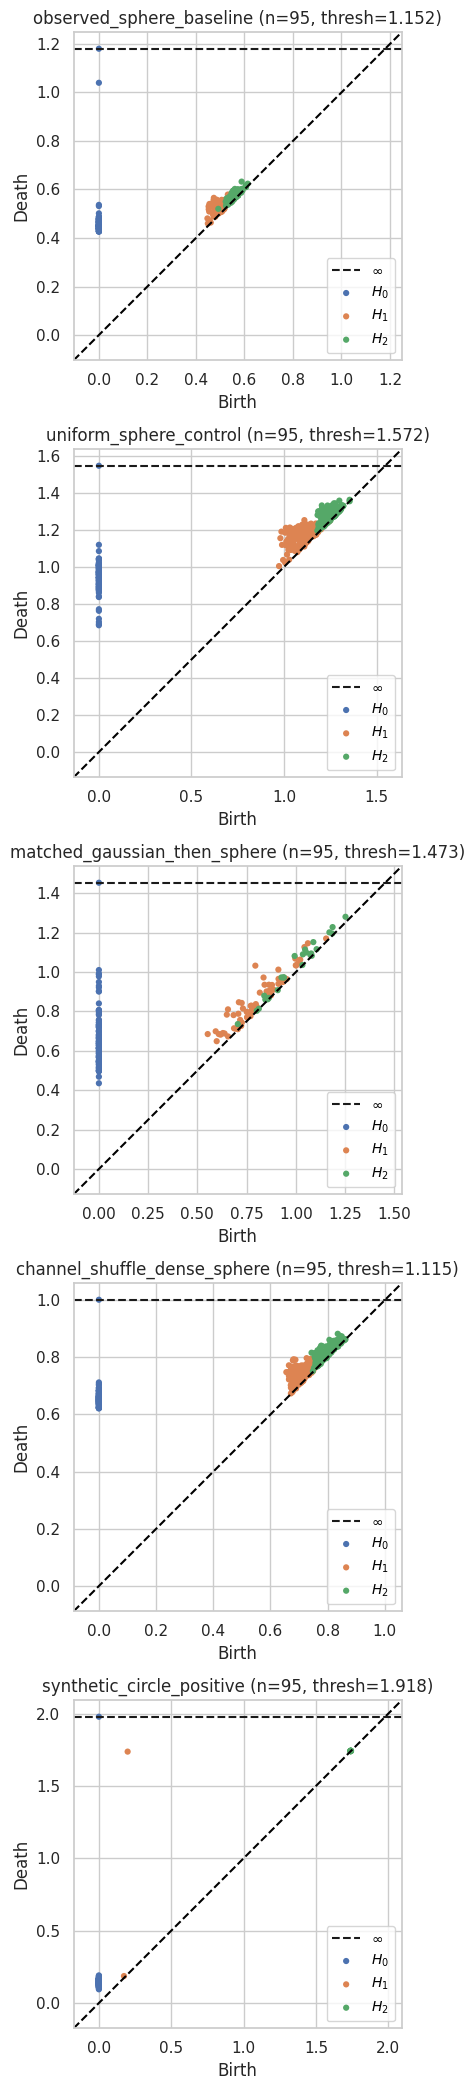

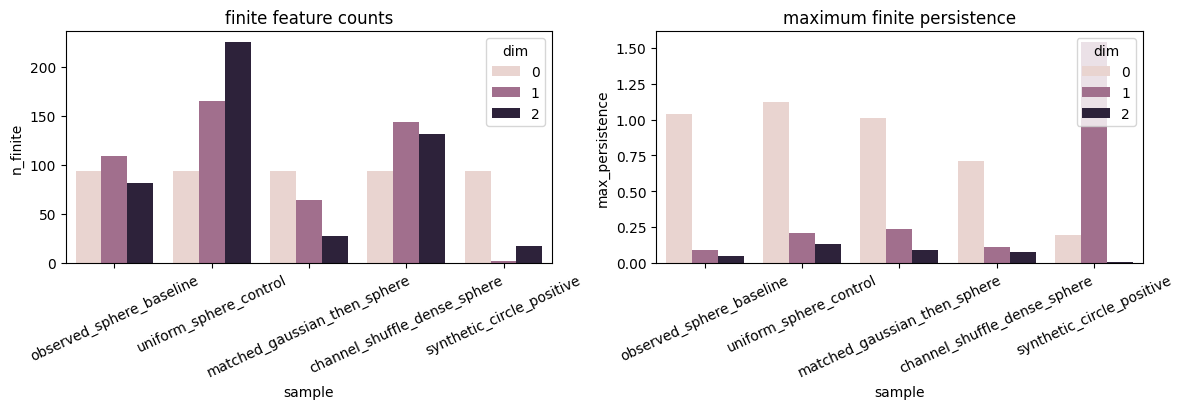

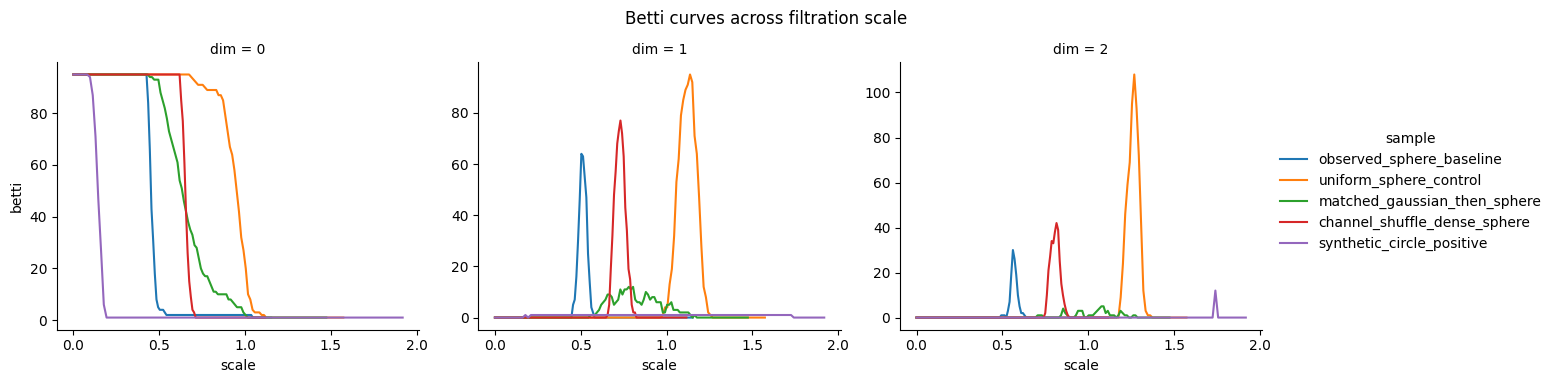

In [10]:
representative_seed = STABILITY_SEEDS[0]
representative_keys = [
    ("control_baseline", representative_seed, "sphere", "observed_sphere_baseline"),
    ("control_baseline", representative_seed, "sphere", "uniform_sphere_control"),
    ("control_baseline", representative_seed, "sphere", "matched_gaussian_then_sphere"),
    ("control_baseline", representative_seed, "sphere", "channel_shuffle_dense_sphere"),
    ("control_baseline", representative_seed, "sphere", "synthetic_circle_positive"),
]
representative_results = [results[key] for key in representative_keys if key in results]
plot_diagrams(representative_results)
plot_persistence_summary(pd.concat([
    summarize_result(
        result,
        seed=representative_seed,
        config="representative",
        view="sphere",
        group="representative",
        n_dense=int(baseline["n_dense"]),
        n_landmarks=int(baseline["n_landmarks"]),
        k_density=int(baseline["k_density"]),
    )
    for result in representative_results
]))
plot_betti_curves(representative_results)

## 9. Longest Bars

The next table lists the longest finite bars for the representative
observed run and for the positive control. This is a quick check that the
circle control really concentrates its strongest signal in `H1`.

In [11]:
top_tables = []
for key in [
    ("control_baseline", representative_seed, "sphere", "observed_sphere_baseline"),
    ("control_baseline", representative_seed, "sphere", "synthetic_circle_positive"),
]:
    if key in results:
        top_tables.append(top_persistence_table(results[key], top_n=8).assign(run_key=str(key)))
display(pd.concat(top_tables, ignore_index=True))

,sample,dim,rank,birth,death,persistence,threshold,run_key
0,observed_sphere_baseline,0,1,0.000000,1.039958,1.039958,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
1,observed_sphere_baseline,0,2,0.000000,0.536561,0.536561,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
2,observed_sphere_baseline,0,3,0.000000,0.531638,0.531638,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
3,observed_sphere_baseline,0,4,0.000000,0.501606,0.501606,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
4,observed_sphere_baseline,0,5,0.000000,0.488604,0.488604,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
5,observed_sphere_baseline,0,6,0.000000,0.486714,0.486714,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
6,observed_sphere_baseline,0,7,0.000000,0.486183,0.486183,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
7,observed_sphere_baseline,0,8,0.000000,0.481074,0.481074,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
8,observed_sphere_baseline,1,1,0.473949,0.565587,0.091637,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."
9,observed_sphere_baseline,1,2,0.455786,0.540415,0.084630,1.151979,"('control_baseline', 72, 'sphere', 'observed_s..."


## 10. Readout

This final cell prints a compact readout for the project log. The most
useful next step is to take any feature that survives here and map the
supporting landmarks or cycles back to image patches.

In [12]:
best_observed = (
    observed_higher
    .groupby(["view", "config", "dim"], as_index=False)["max_persistence_fraction"]
    .mean()
    .sort_values("max_persistence_fraction", ascending=False)
    .head(8)
)
best_controls = (
    baseline_summary
    .groupby(["sample", "dim"], as_index=False)["max_persistence_fraction"]
    .mean()
    .sort_values("max_persistence_fraction", ascending=False)
    .head(8)
)

print("Runtime recap")
print(f"  encode seconds: {encode_seconds:.2f}")
print(f"  sweep seconds:  {sweep_seconds:.2f}")
print(f"  diagram runs:   {len(results)}")
print()
print("Strongest observed FLUX settings by normalized persistence:")
display(best_observed.round(4))
print("Strongest baseline/control settings by normalized persistence:")
display(best_controls.round(4))

readout_rows = []
for sample_name in ["observed_sphere_baseline", "uniform_sphere_control", "matched_gaussian_then_sphere", "channel_shuffle_dense_sphere", "synthetic_circle_positive"]:
    row = effect[(effect["sample"] == sample_name) & (effect["dim"] == 1)]
    if not row.empty:
        readout_rows.append(
            {
                "sample": sample_name,
                "h1_mean_persistence_fraction": float(row["mean"].iloc[0]),
                "h1_delta_vs_uniform": float(row["delta_vs_uniform"].iloc[0]),
            }
        )
readout = pd.DataFrame(readout_rows).sort_values("h1_mean_persistence_fraction", ascending=False)
print("H1 baseline readout")
display(readout.round(4))
print(
    "Interpretation prompt: if observed_sphere_baseline is not clearly above the null controls, "
    "treat the single-run diagram from notebook 06 as pipeline-sensitive rather than as evidence "
    "for a stable FLUX-specific loop."
)

Runtime recap
  encode seconds: 6.55
  sweep seconds:  4.77
  diagram runs:   60

Strongest observed FLUX settings by normalized persistence:


,view,config,dim,max_persistence_fraction
14,whitened,fewer_landmarks,1,0.1155
16,whitened,smaller_dense,1,0.1154
12,whitened,baseline,1,0.1090
6,sphere,baseline,1,0.0834
10,sphere,smaller_dense,1,0.0823
0,raw,baseline,1,0.0786
4,raw,smaller_dense,1,0.0762
17,whitened,smaller_dense,2,0.0714


Strongest baseline/control settings by normalized persistence:


,sample,dim,max_persistence_fraction
8,synthetic_circle_positive,1,0.8040
10,uniform_sphere_control,1,0.1387
6,random_sphere_tokens,1,0.1364
2,matched_gaussian_then_sphere,1,0.1318
0,channel_shuffle_dense_sphere,1,0.1071
4,observed_sphere_baseline,1,0.0834
11,uniform_sphere_control,2,0.0776
1,channel_shuffle_dense_sphere,2,0.0681


H1 baseline readout


,sample,h1_mean_persistence_fraction,h1_delta_vs_uniform
4,synthetic_circle_positive,0.8040,0.6653
1,uniform_sphere_control,0.1387,0.0000
2,matched_gaussian_then_sphere,0.1318,-0.0069
3,channel_shuffle_dense_sphere,0.1071,-0.0316
0,observed_sphere_baseline,0.0834,-0.0553


Interpretation prompt: if observed_sphere_baseline is not clearly above the null controls, treat the single-run diagram from notebook 06 as pipeline-sensitive rather than as evidence for a stable FLUX-specific loop.
